# Pentadic Tone-Space: Wilson's Eikosany and Hexadic Diamond from A4 Coxeter Theory

Erv Wilson's pentadic constructions -- the 31-point **Hexadic Diamond** and 20-point **Eikosany** built from the 6-set $\{1, 3, 5, 7, 9, 11\}$ -- are derived here from the A4 root system. **Two distinct readings of the same Generating Hexad pentagon** produce the two constructions: *edge-as-root* yields the Diamond (Section A); *edge-as-sum* yields the Eikosany (Section B). The organising principle throughout is Pascal's Triangle.

Wilson's source figures appear in `dal.pdf`: Figure 1, Pascal's Triangle; Figure 13, Eikosany with Generating Hexad; Figure 14, Hexadic Diamond with Major / Minor Hexads.

## Pascal's Triangle

Wilson opens *D'Alessandro, like a Hurricane* with Pascal's Triangle. The 6-set $\{1, 3, 5, 7, 9, 11\}$ admits

$$ \binom{6}{3} \;=\; 20 $$

combinations of three elements -- these are the Eikosany pitches. Pascal's recursion

$$ \binom{6}{3} \;=\; \binom{5}{2} + \binom{5}{3} \;=\; 10 + 10 $$

decomposes those 20 into two halves: 10 triples *containing* 1 (which reduce to products of two harmonics $1 \cdot P_i \cdot P_j$) and 10 *not containing* 1 (products of three harmonic factors $P_i \cdot P_j \cdot P_k$).  It is noted that the "$\binom{5}{2}$ 3-5-7-9-11 Dekany" and "$\binom{5}{3}$ 3-5-7-9-11 Dekany" provide coverage of the Eikosany on p. 170 of "Microtonality and the Tuning Systems of Erv Wilson" by Terumi Narushima.

This is the bridge to **Pascal Row 5** $\;=\; (1, 5, 10, 10, 5, 1)$. The recursion's LHS counts subsets of an *explicit*-unity 6-set; its RHS counts subsets of an *implicit*-unity 5-set $\{3, 5, 7, 9, 11\}$. Adopting Coxeter theory on $A_4$ -- rank 4, ambient dimension 5 -- maps the five odd-prime generators to basis vectors $\varepsilon_1, \dots, \varepsilon_5$, and lifts unity to the origin (implicit, never one of the five generators). Pascal Row 5 then aligns with the $W(A_4)$-orbit sizes on the fundamental-weight lattice:

| Row 5 entry | $W(A_4)$ orbit | Form | Musical role |
|---|---|---|---|
| 1 | (origin) | $0$ | unison -- implicit unity |
| 5 | $W \cdot \Lambda_1$ | $+\varepsilon_i$ | otonals $\{3, 5, 7, 9, 11\}$ |
| 10 | $W \cdot \Lambda_2$ | $\varepsilon_i + \varepsilon_j$ | Eikosany "with 1" |
| 10 | $W \cdot \Lambda_3$ | $\varepsilon_i + \varepsilon_j + \varepsilon_k$ | Eikosany "no 1" |
| 5 | $W \cdot \Lambda_4 \equiv -\Lambda_1 \pmod{\mathbf{1}}$ | $-\varepsilon_i$ | utonals $\{1/3, 1/5, \dots\}$ |
| 1 | (complement) | $\mathbf{1} = (1,1,1,1,1)$ | the octave -- implicit endpoint |

The first and last Row-5 entries are implicit endpoints -- the origin (unison) and the octave -- bracketing the scale structure without themselves appearing as scale notes.  [Note that $(1,1,1,1,1)$ is normal to the Coxeter plane (the 2D projection used for the Hexadic Diamond and Eikosany) as so is projected to the origin.]

The notebook unfolds in two parallel sections, each drawing different orbits from this table:

- **Section A -- Hexadic Diamond** uses $\Lambda_1$ (signed) for the Major / Minor Hexad vertices and the $A_4$ root system $\Phi$ for the dyad-edge vectors. Diamond $= \{0\} \sqcup (W{\cdot}\Lambda_1) \sqcup -(W{\cdot}\Lambda_1) \sqcup \Phi$, with sizes $1 + 5 + 5 + 20 = 31$.

- **Section B -- Eikosany** uses $\Lambda_1$ for the Generating Hexad's vertices, $W{\cdot}\Lambda_2$ to index its 10 dyad-edges (pairs), and $W{\cdot}\Lambda_3$ to index its 10 triangles (triples). Eikosany $= (W{\cdot}\Lambda_2) \sqcup (W{\cdot}\Lambda_3)$, with size $10 + 10 = 20$.

The Generating (major) Hexad pentagon _looks identical_ in both sections -- Wilson uses the same pentagonal drawing for both Figure 13 and Figure 14. What differs is the *legend*: dyad-edge labels in Section A are root vectors $\varepsilon_i - \varepsilon_j$; in Section B they are dyad ratios $P_i : P_j$ giving musical interval between two vertices. Same picture, two arithmetic operations on the same indexed pairs.

In [1]:
import sys
sys.path.insert(0, '../src')

import itertools
import numpy as np
import matplotlib.pyplot as plt
from sympy import Rational

from coxeter_a4 import build_a4_system, build_eigenspaces, eigenvec_to_proj

In [2]:
R, ambient, W, s, cox, P = build_a4_system()
K, zeta, w_par, w_perp = build_eigenspaces(P)
proj = eigenvec_to_proj(w_par, K)

P_np = np.array(P, dtype=int)
eps = [ambient.basis()[i] for i in ambient.basis().keys()]
primes = [3, 5, 7, 9, 11]   # the five odd-prime-equivalent generators

print('A4 Coxeter element c = s1 s2 s3 s4  (cyclic permutation epsilon_i -> epsilon_{i+1}):')
print(P_np)
print()
print('2D projection pi : R^5 -> E_parallel  (rotation by 2pi/5 per Coxeter step):')
print(np.round(proj, 4))

A4 Coxeter element c = s1 s2 s3 s4  (cyclic permutation epsilon_i -> epsilon_{i+1}):
[[0 0 0 0 1]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]]

2D projection pi : R^5 -> E_parallel  (rotation by 2pi/5 per Coxeter step):
[[ 0.6325  0.1954 -0.5117 -0.5117  0.1954]
 [-0.      0.6015  0.3717 -0.3717 -0.6015]]


## Pascal Row 5 $\leftrightarrow$ $W(A_4)$ fundamental-weight orbits

Build the four $W(A_4)$ orbits of the fundamental weights $\Lambda_1, \Lambda_2, \Lambda_3, \Lambda_4$ explicitly. Their sizes are Pascal Row 5 entries (excluding the two implicit endpoints).

In [3]:
Lambda = ambient.fundamental_weights()

def orbit_5D(k):
    """W(A4)-orbit of the k-th fundamental weight as integer 5D vectors."""
    return np.array([np.array(v.to_vector(), dtype=int)
                     for v in Lambda[k].orbit()])

L1 = orbit_5D(1)
L2 = orbit_5D(2)
L3 = orbit_5D(3)
L4 = orbit_5D(4)

print('Pascal Row 5  <->  W(A4) fundamental-weight orbit sizes:')
print(f'  C(5,1) = {len(L1):2d}    W.Lambda_1   otonals           (+epsilon_i)')
print(f'  C(5,2) = {len(L2):2d}    W.Lambda_2   two harmonics     (epsilon_i + epsilon_j)             - Eikosany "with 1"')
print(f'  C(5,3) = {len(L3):2d}    W.Lambda_3   three harmonics   (epsilon_i + epsilon_j + epsilon_k) - Eikosany "no 1"')
print(f'  C(5,4) = {len(L4):2d}    W.Lambda_4   utonals           (= -epsilon_i mod ones-vector)')
print()
print('Implicit endpoints: C(5,0) = 1 (origin / unison),  C(5,5) = 1 (ones-vector / octave)')

Pascal Row 5  <->  W(A4) fundamental-weight orbit sizes:
  C(5,1) =  5    W.Lambda_1   otonals           (+epsilon_i)
  C(5,2) = 10    W.Lambda_2   two harmonics     (epsilon_i + epsilon_j)             - Eikosany "with 1"
  C(5,3) = 10    W.Lambda_3   three harmonics   (epsilon_i + epsilon_j + epsilon_k) - Eikosany "no 1"
  C(5,4) =  5    W.Lambda_4   utonals           (= -epsilon_i mod ones-vector)

Implicit endpoints: C(5,0) = 1 (origin / unison),  C(5,5) = 1 (ones-vector / octave)


In [4]:
# JI ratio (sympy Rational) for a 5D lattice vector under the mapping epsilon_i -> primes[i]
def ratio(v_5D):
    num = den = 1
    for p, e in zip(primes, v_5D):
        if   e > 0: num *= p ** int(e)
        elif e < 0: den *= p ** int(-e)
    return Rational(num, den)

def octave_reduce(r):
    while r > 2: r = r / 2
    while r < 1: r = r * 2
    return r

# Root-vector label for the dyad-edge-as-root reading (Section A): 'epsilon_i - epsilon_j'
def root_label(r5):
    i = int((r5 ==  1).argmax()) + 1
    j = int((r5 == -1).argmax()) + 1
    return f'e{i}-e{j}'

# Dyad-pair label for the dyad-edge-as-sum reading (Section B): 'p_i : p_j'
def dyad_label(r5):
    i = int((r5 ==  1).argmax())
    j = int((r5 == -1).argmax())
    return f'{primes[i]}:{primes[j]}'

# Product label for Eikosany lattice points: '1.3.5' (Lambda_2) or '3.5.7' (Lambda_3)
def product_label(v_5D):
    factors = [str(p) for p, e in zip(primes, v_5D) for _ in range(int(e))]
    if int(sum(v_5D)) == 2:   # Lambda_2: prepend implicit unity
        factors = ['1'] + factors
    return '.'.join(factors)

## A) The Hexadic Diamond via $A_4$ roots

The first reading of the Generating Hexad treats each of its 10 dyad-edges as a **root vector** $\alpha_{ij} = \varepsilon_i - \varepsilon_j$ -- an element of the $A_4$ root system $\Phi$. Two Hexads appear, mirroring each other:

- **Major Hexad**: 5 otonal vertices $+\varepsilon_i \in W \cdot \Lambda_1$ joined by 10 positive-root dyad-edge vectors $\Phi^+$.
- **Minor Hexad**: 5 utonal vertices $-\varepsilon_i \in -(W \cdot \Lambda_1)$ joined by 10 negative-root dyad-edge vectors $\Phi^-$.

The Diamond is then assembled by promoting each root dyad-edge vector to an origin-anchored position point, and overlaying both pentagons plus the origin:

$$ \mathrm{Diamond} \;=\; \{0\} \;\sqcup\; (W{\cdot}\Lambda_1) \;\sqcup\; -(W{\cdot}\Lambda_1) \;\sqcup\; \Phi $$

with sizes $1 + 5 + 5 + 20 = 31$. The 20 roots are *position* points in the Diamond -- they sit at projected locations $\pi(\varepsilon_i - \varepsilon_j) = P_i - P_j$, intermediate to the otonal and utonal pentagons.

Wilson labels the otonal pentagon "MAJOR HEXAD" and the utonal pentagon "MINOR HEXAD" in Wilson's Figure 14.

In [5]:
# Otonal and utonal vertex sets (signed Lambda_1)
otonal_5D = L1
utonal_5D = -L1

# Positive and negative roots
pos_roots = np.array([np.array(r.to_vector(), dtype=int) for r in ambient.positive_roots()])
neg_roots = -pos_roots

# Anchor index: for each root, the position of -1 (positive root) or +1 (negative root)
# identifies the otonal/utonal endpoint the dyad-edge is anchored at.
pr_from = (pos_roots == -1).argmax(axis=1)
nr_from = (neg_roots ==  1).argmax(axis=1)

# 2D projections
pr_proj     = pos_roots  @ proj.T
nr_proj     = neg_roots  @ proj.T
otonal_proj = otonal_5D  @ proj.T
utonal_proj = utonal_5D  @ proj.T

# Root-vector legend labels (Section A reading)
pr_root_labels = [root_label(r) for r in pos_roots]
nr_root_labels = [root_label(r) for r in neg_roots]

In [6]:
def draw_hexad(ax, root_segs, anchors, anchor_idx, labels, vertex_color, title,
               dyad_color_seq=None):
    """Render one hexad on `ax`: anchored K_5 dyad-edges, origin radii, and vertex markers.

    Each K_5 dyad-edge between two vertices is drawn as the segment from the anchor vertex
    along the root segment to the second vertex. Five additional radii from the origin
    to each anchor complete the K_6 figure that Wilson draws.

    The 2D coordinates are rotated 90 degrees, (x, y) -> (-y, x), to match Wilson\u2019s
    orientation (otonal vertex 3 at the top).

    `dyad_color_seq`: optional list/array of one matplotlib color per dyad-edge. If supplied,
    edges are drawn in these explicit colors (so an edge direction can be made consistent
    with later figures that translate the same root vector elsewhere). Defaults to
    matplotlib\u2019s auto color cycle.

    Line-thickness convention: origin radii (whose vectors are the 5 Lambda_1 elements)
    are drawn thick; K_5 dyad-edges (whose vectors are root projections e_i - e_j) are
    drawn thin -- so the structurally fundamental Lambda_1 lines are visually emphasized
    over the derived root projections.
    """
    for k, r in enumerate(root_segs):
        a = anchors[anchor_idx[k]]
        seg = np.vstack((a, a + r))
        kwargs = dict(label=labels[k], linewidth=0.8)
        if dyad_color_seq is not None:
            kwargs["color"] = dyad_color_seq[k]
        ax.plot(-seg[:, 1], seg[:, 0], **kwargs)

    for v in anchors:
        ax.plot([0, -v[1]], [0, v[0]], color=vertex_color, linewidth=1.5)

    ax.scatter(-anchors[:, 1], anchors[:, 0], c=vertex_color, s=60, zorder=3)
    ax.scatter([0], [0], c="k", s=40, zorder=3)

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(bbox_to_anchor=(1.0, 1.0), fontsize=8)

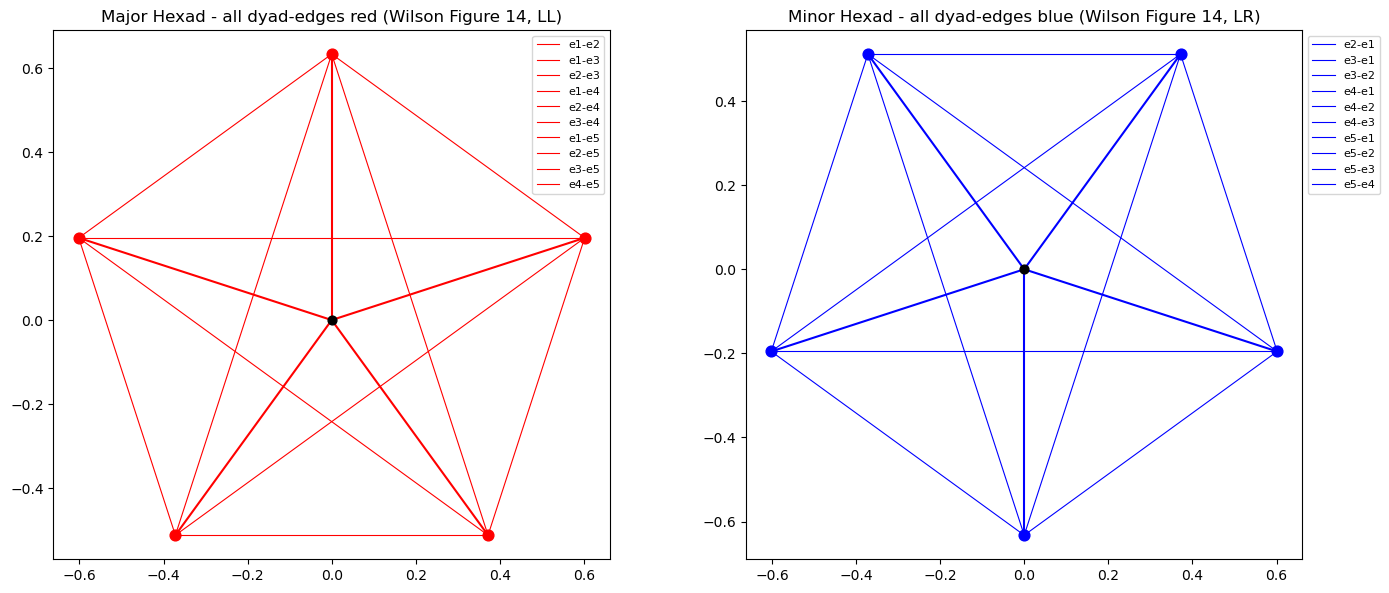

In [7]:
# Section A color convention: all Major dyad-edges red, all Minor dyad-edges blue.
# The per-edge legend labels (root vectors) are preserved as identifiers, but the
# uniform color emphasizes the Major / Minor duality that the Diamond plot below
# (and Wilson\u2019s Figure 14) make central.
pr_dyad_colors_red  = ["r"] * len(pos_roots)
nr_dyad_colors_blue = ["b"] * len(neg_roots)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

draw_hexad(axes[0], pr_proj, otonal_proj, pr_from, pr_root_labels,
           vertex_color="r",
           title="Major Hexad - all dyad-edges red (Wilson Figure 14, LL)",
           dyad_color_seq=pr_dyad_colors_red)

draw_hexad(axes[1], nr_proj, utonal_proj, nr_from, nr_root_labels,
           vertex_color="b",
           title="Minor Hexad - all dyad-edges blue (Wilson Figure 14, LR)",
           dyad_color_seq=nr_dyad_colors_blue)

plt.tight_layout()
plt.show()

### From Major / Minor Hexads to the Hexadic Diamond

Each dyad-edge of the two Hexads is a *root vector* $\pi(\varepsilon_i - \varepsilon_j) = P_i - P_j$ -- a translation, not yet a position. Promoting each root vector to an origin-anchored *position* point yields the 20 root-points of the Diamond, which sit between the otonal and utonal pentagons. Overlaying the origin (1), the 5 otonals $+\varepsilon_i$, the 5 utonals $-\varepsilon_i$, and the 20 roots produces the full 31-point Hexadic Diamond (Wilson's Figure 14, main).

The figure below adopts Wilson's Major / Minor color convention: **red** lines mark the *Major* structure (the otonal outer pentagon plus the Coxeter-orbit V-belt and origin radii on the otonal-leaning root cluster); **blue** lines mark the *Minor* structure (utonal pentagon, V-belt, radii on the utonal-leaning root cluster); the **grey** outer decagon is the 10-point convex hull that bridges the two halves. The V-belt -- a 5-fold Coxeter-element orbit on a chosen root seed -- agrees with Wilson's rendering in Figure 14.

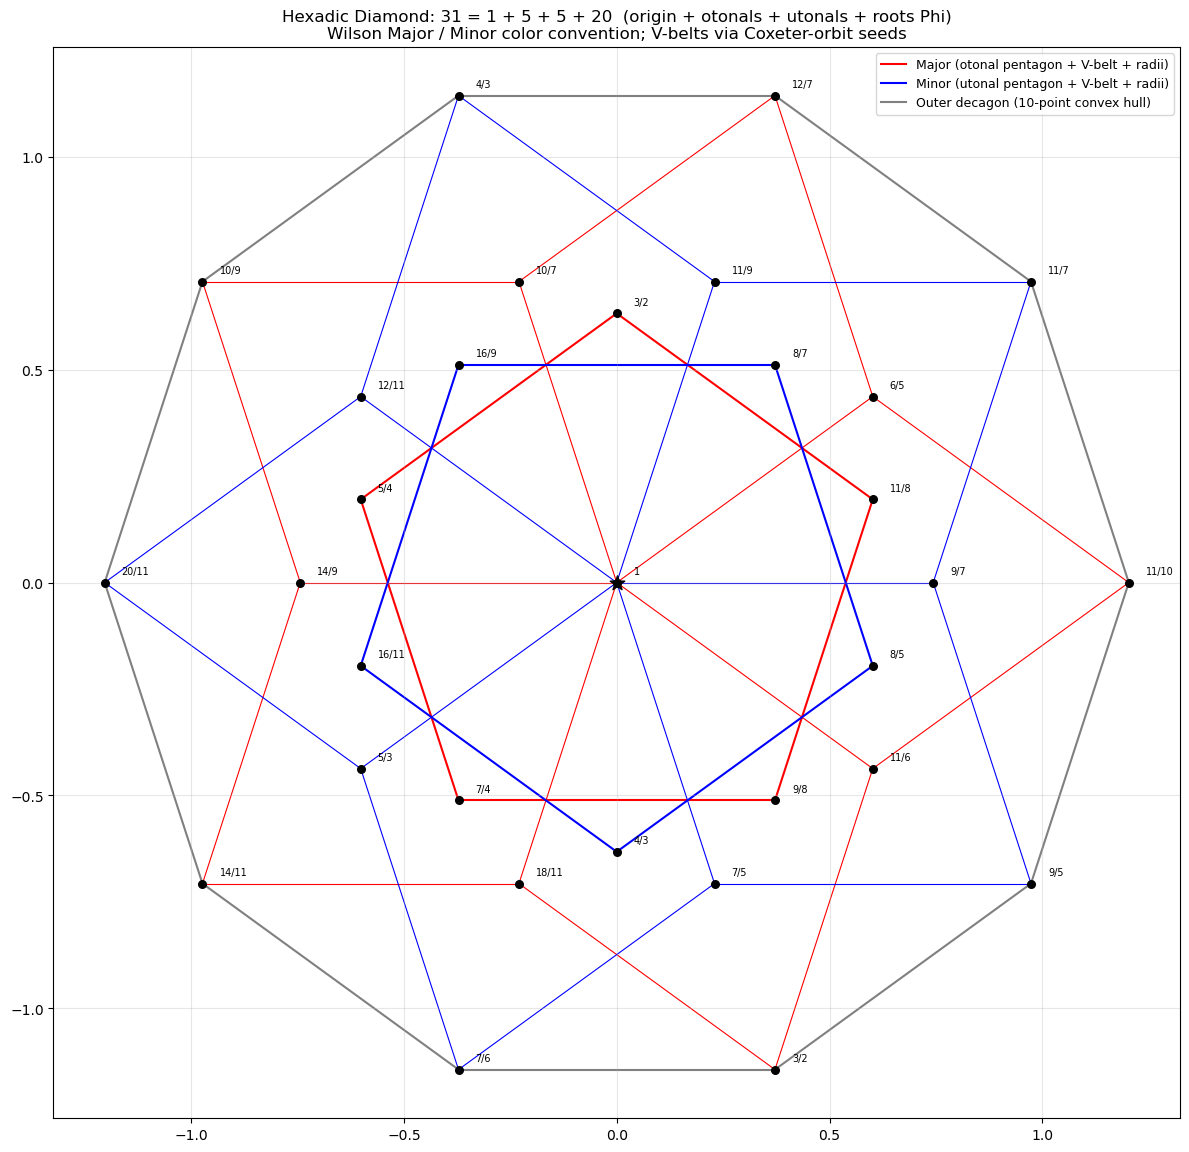

In [11]:
# Assemble the 31-point Diamond
roots_5D = np.array([np.array(r.to_vector(), dtype=int)
                     for r in ambient.roots()])
diamond_5D = np.vstack([np.zeros((1, 5), dtype=int),
                        otonal_5D, utonal_5D, roots_5D])

# Diamond filter: at most one +1 and at most one -1 per row (Wilson's defining property)
assert all((np.sum(pt < 0) < 2) and (np.sum(pt > 0) < 2) for pt in diamond_5D)
assert len(diamond_5D) == 31

xy_d = diamond_5D @ proj.T
x_d  = -xy_d[:, 1]
y_d  =  xy_d[:, 0]

# ---- V-belt helpers (lifted from hexadic_diamond_coxeter.ipynb) ----
def coxeter_orbit(base, n=5):
    """C_5 orbit of `base` (a 5D integer vector) under repeated application of P."""
    orbit = [np.array(base, dtype=int)]
    for _ in range(n - 1):
        orbit.append(P_np @ orbit[-1])
    return [list(int(x) for x in v) for v in orbit]

def find_diamond_idx(pt5):
    """Return the index of `pt5` in diamond_5D, or None if absent."""
    arr = np.asarray(pt5, dtype=int)
    matches = np.where((diamond_5D == arr).all(axis=1))[0]
    return int(matches[0]) if len(matches) else None

def draw_vbelt(ax, outer_seeds, bridge_seeds, color, lw=0.8):
    """5-fold V-shape belt: outer[k] -> bridge[k] -> outer[k+1] for k = 0..4."""
    for k in range(5):
        i_o1 = find_diamond_idx(outer_seeds[k])
        i_br = find_diamond_idx(bridge_seeds[k])
        i_o2 = find_diamond_idx(outer_seeds[(k + 1) % 5])
        if None not in (i_o1, i_br, i_o2):
            ax.plot([x_d[i_o1], x_d[i_br]], [y_d[i_o1], y_d[i_br]],
                    color=color, linewidth=lw, zorder=0)
            ax.plot([x_d[i_br], x_d[i_o2]], [y_d[i_br], y_d[i_o2]],
                    color=color, linewidth=lw, zorder=0)

def draw_convex_pentagon(ax, point_indices, color, lw=1.5):
    """Connect 5 points in angular order around the origin."""
    angs = np.arctan2([y_d[i] for i in point_indices],
                      [x_d[i] for i in point_indices])
    ordered = [point_indices[k] for k in np.argsort(angs)]
    for k in range(5):
        i, j = ordered[k], ordered[(k + 1) % 5]
        ax.plot([x_d[i], x_d[j]], [y_d[i], y_d[j]],
                color=color, linewidth=lw, zorder=0)

# ---- Build the figure ----
fig, ax = plt.subplots(figsize=(12, 12))

# Outer red pentagon (otonal vertices, diamond_5D indices 1..5)
draw_convex_pentagon(ax, list(range(1, 6)), "r", lw=1.5)

# Red V-belt: outer seed e_1 - e_3, bridge seed e_2 - e_3 (Coxeter-orbit on the
# otonal-leaning root cluster; same seeds as hexadic_diamond_coxeter.ipynb)
red_outer  = coxeter_orbit([ 1, 0, -1, 0, 0])
red_bridge = coxeter_orbit([ 0, 1, -1, 0, 0])
draw_vbelt(ax, red_outer, red_bridge, "r", lw=0.8)

# Red radii from origin to the 5 red-bridge root points
for v in red_bridge:
    i = find_diamond_idx(v)
    if i is not None:
        ax.plot([0, x_d[i]], [0, y_d[i]], color="r", linewidth=0.8, zorder=0)

# Outer blue pentagon (utonal vertices, diamond_5D indices 6..10)
draw_convex_pentagon(ax, list(range(6, 11)), "b", lw=1.5)

# Blue V-belt: negation of the red seeds
blue_outer  = coxeter_orbit([-1, 0,  1, 0, 0])
blue_bridge = coxeter_orbit([ 0, -1, 1, 0, 0])
draw_vbelt(ax, blue_outer, blue_bridge, "b", lw=0.8)

# Blue radii from origin
for v in blue_bridge:
    i = find_diamond_idx(v)
    if i is not None:
        ax.plot([0, x_d[i]], [0, y_d[i]], color="b", linewidth=0.8, zorder=0)

# Grey outer decagon: convex hull of the 10 outermost points (alternating otonal / utonal)
distances    = np.sqrt(x_d**2 + y_d**2)
idx_outer10  = list(np.argsort(distances)[-10:])
angs10       = np.arctan2([y_d[i] for i in idx_outer10],
                          [x_d[i] for i in idx_outer10])
idx_outer10  = [idx_outer10[k] for k in np.argsort(angs10)]
for k in range(10):
    i, j = idx_outer10[k], idx_outer10[(k + 1) % 10]
    ax.plot([x_d[i], x_d[j]], [y_d[i], y_d[j]],
            color="grey", linewidth=1.5, zorder=0)

# Markers and origin
ax.scatter(x_d, y_d, color="k", s=30, zorder=3)
ax.scatter([0], [0], color="k", s=120, marker="*", zorder=4)

# Octave-reduced JI ratio annotations
for k, v in enumerate(diamond_5D):
    r = octave_reduce(ratio(v))
    ax.annotate(str(r), xy=(x_d[k] + 0.04, y_d[k] + 0.02), fontsize=7, zorder=5)

# Compact 3-entry legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="r",    linewidth=1.5,
           label="Major (otonal pentagon + V-belt + radii)"),
    Line2D([0], [0], color="b",    linewidth=1.5,
           label="Minor (utonal pentagon + V-belt + radii)"),
    Line2D([0], [0], color="grey", linewidth=1.5,
           label="Outer decagon (10-point convex hull)"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)

ax.set_aspect("equal")
ax.set_title(f"Hexadic Diamond: {len(diamond_5D)} = 1 + 5 + 5 + 20  "
             f"(origin + otonals + utonals + roots Phi)\n"
             f"Wilson Major / Minor color convention; V-belts via Coxeter-orbit seeds")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../pentadic_hexadic_diamond.png')
plt.show()

## Section B -- The Eikosany via fundamental-weight orbits

The second reading of the same Generating Hexad reinterprets its geometric content through **fundamental-weight orbits** rather than roots. The pentagonal drawing is unchanged; the *arithmetic operation* on the index pairs flips from difference to sum:

| Hexad feature | Indexing orbit | Construction | Pascal Row 5 entry |
|---|---|---|---|
| 5 vertices | $W \cdot \Lambda_1$ | $+\varepsilon_i$ | $\binom{5}{1} = 5$ |
| 10 dyad-edges (pairs $\{i,j\}$) | $W \cdot \Lambda_2$ | $\varepsilon_i + \varepsilon_j$ | $\binom{5}{2} = 10$ |
| 10 triangles (triples $\{i,j,k\}$) | $W \cdot \Lambda_3$ | $\varepsilon_i + \varepsilon_j + \varepsilon_k$ | $\binom{5}{3} = 10$ |

The dyad-edge between vertices $\varepsilon_i$ and $\varepsilon_j$ no longer represents the *difference* $\varepsilon_i - \varepsilon_j$ (a root); it now indexes the *sum* $\varepsilon_i + \varepsilon_j$ (an element of $\Lambda_2$). Wilson labels this pentagon "GENERATING HEXAD" in his Figure 13 -- distinct from the Figure 14 "MAJOR HEXAD" name, even though the drawing is identical.

**Edge vs. point disambiguation.** Each Hexad dyad-edge bijects to one $W{\cdot}\Lambda_2$ pair-product point in the Eikosany figure, but the two are *geometrically distinct objects sharing an index*. The dyad-edge is the **line** from generator $\varepsilon_i$ to generator $\varepsilon_j$ in the Hexad (projected to the segment from $P_i$ to $P_j$); the pair-product point is the **single lattice point** $\varepsilon_i + \varepsilon_j$ in the Eikosany (projected to $P_i + P_j$, off the edge and twice as far from origin). The Hexad draws lines but not their indexed pair-product points; the Eikosany draws the pair-product points but not the inter-vertex lines.

Note the asymmetry with Section A: the Eikosany lives entirely in the positive cone (all orbit elements have non-negative coordinates), so **only the otonal Generating Hexad is needed** -- there is no Minor analogue here. This is the "implicit unity" pattern at work: every Eikosany pitch is reached by *positive* combination of the five generators $\{3, 5, 7, 9, 11\}$.

**Color convention switch.** Section A used a 2-color (red / blue) scheme to emphasize Wilson’s Major / Minor duality. Section B’s figures below adopt a *different* convention: each of the 10 dyad-edge directions gets its own color (10 distinct colors from `tab10`), and these same colors are reused for parallel translates in the Eikosany figure -- so a dyad-edge in the Generating Hexad and its 6 same-direction translates among the Eikosany pair-products / triple-products all share a color. The two conventions answer different questions: red / blue exposes Major / Minor; per-direction colors expose edge-as-translation.

W.Lambda_2 orbit  ->  Generating Hexad dyad-edges on the W.Lambda_1 pentagon:
  (10 pair-products from orbit_5D(2), built via Lambda[2].orbit() in SageMath)

  (1, 1, 0, 0, 0)  =  e1 + e2  ->  dyad-edge (3, 5)   pair-product pitch = 1.3.5 = 15
  (1, 0, 1, 0, 0)  =  e1 + e3  ->  dyad-edge (3, 7)   pair-product pitch = 1.3.7 = 21
  (0, 1, 1, 0, 0)  =  e2 + e3  ->  dyad-edge (5, 7)   pair-product pitch = 1.5.7 = 35
  (1, 0, 0, 1, 0)  =  e1 + e4  ->  dyad-edge (3, 9)   pair-product pitch = 1.3.9 = 27
  (0, 1, 0, 1, 0)  =  e2 + e4  ->  dyad-edge (5, 9)   pair-product pitch = 1.5.9 = 45
  (1, 0, 0, 0, 1)  =  e1 + e5  ->  dyad-edge (3, 11)   pair-product pitch = 1.3.11 = 33
  (0, 0, 1, 1, 0)  =  e3 + e4  ->  dyad-edge (7, 9)   pair-product pitch = 1.7.9 = 63
  (0, 1, 0, 0, 1)  =  e2 + e5  ->  dyad-edge (5, 11)   pair-product pitch = 1.5.11 = 55
  (0, 0, 1, 0, 1)  =  e3 + e5  ->  dyad-edge (7, 11)   pair-product pitch = 1.7.11 = 77
  (0, 0, 0, 1, 1)  =  e4 + e5  ->  dyad-edge (9, 11)   pair-pr

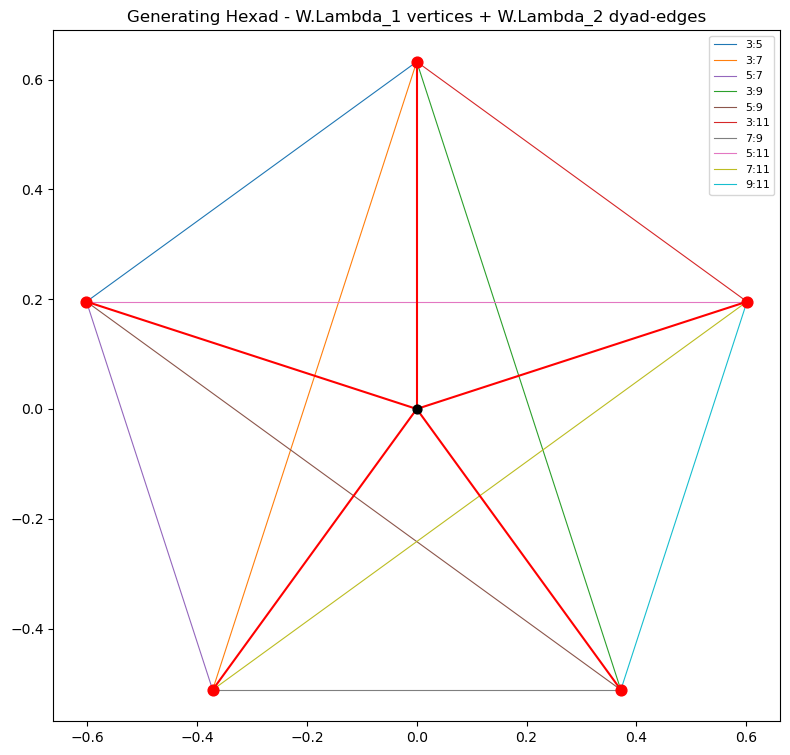

In [9]:
# Build the Generating Hexad explicitly from W(A4) orbits:
#   W.Lambda_1 (5 vertices)  ->  pentagon corners
#   W.Lambda_2 (10 pair-products)    ->  dyad-edges (index pairs)
#
# Each Lambda_2 element  v = epsilon_i + epsilon_j  has +1 at exactly two coordinate
# positions; those positions identify the two L1 vertices the dyad-edge connects.

def dyad_to_pair(v_5D):
    """Return the ordered pair (i, j), i < j, of L1 indices a Lambda_2 element spans."""
    idx = np.where(v_5D == 1)[0]
    return int(idx[0]), int(idx[1])

l2_pairs = [dyad_to_pair(v) for v in L2]

print("W.Lambda_2 orbit  ->  Generating Hexad dyad-edges on the W.Lambda_1 pentagon:")
print(f"  (10 pair-products from orbit_5D(2), built via Lambda[2].orbit() in SageMath)\n")
for v, (i, j) in zip(L2, l2_pairs):
    coords = tuple(int(x) for x in v)
    print(f"  {coords}  =  e{i+1} + e{j+1}  ->  dyad-edge ({primes[i]}, {primes[j]})"
          f"   pair-product pitch = 1.{primes[i]}.{primes[j]} = {primes[i]*primes[j]}")

# Color-by-slope convention: each unordered pair (i, j) -- one pair-product -- gets a distinct
# color from tab10. The same dyad_colors dict is reused in the Eikosany plot below so
# that any line connecting two Eikosany points whose difference is the root  e_i - e_j
# is drawn in the matching color. Parallel lines (same slope = same root direction)
# therefore share a color in both the Generating Hexad and the Eikosany figure.
dyad_colors = {(i, j): plt.cm.tab10(k)
               for k, (i, j) in enumerate(itertools.combinations(range(5), 2))}

# Vertex positions (2D) from L1; dyad-edge vectors, anchors, labels, and colors from l2_pairs
otonal_xy    = L1 @ proj.T
gh_edge_vecs = np.array([otonal_xy[j] - otonal_xy[i] for (i, j) in l2_pairs])
gh_anchor_ix = np.array([i for (i, j) in l2_pairs])
gh_labels    = [f"{primes[i]}:{primes[j]}" for (i, j) in l2_pairs]
gh_colors    = [dyad_colors[(i, j)]        for (i, j) in l2_pairs]

fig, ax = plt.subplots(figsize=(8, 8))
draw_hexad(ax, gh_edge_vecs, otonal_xy, gh_anchor_ix, gh_labels,
           vertex_color="r",
           title="Generating Hexad - W.Lambda_1 vertices + W.Lambda_2 dyad-edges",
           dyad_color_seq=gh_colors)
plt.tight_layout()
plt.show()

### Dyad-edge vectors as Eikosany translations

The 10 dyad-edge *vectors* of the Generating Hexad remain root projections, $\pi(\varepsilon_j - \varepsilon_i) = P_j - P_i$. Under the sum reading they play a second geometric role: they are exactly the **translation generators** that move one Eikosany pair-product point to another. For any $k \notin \{i, j\}$,

$$ (\varepsilon_j + \varepsilon_k) \;-\; (\varepsilon_i + \varepsilon_k) \;=\; \varepsilon_j - \varepsilon_i, $$

so the Eikosany segment from pair-product point $P_i + P_k$ to $P_j + P_k$ has *the same vector and length* as the Hexad dyad-edge from $P_i$ to $P_j$. The analogous identity holds for triple-products, replacing one summand $\varepsilon_i$ by $\varepsilon_j$. Each Hexad dyad-edge therefore appears in the Eikosany as **six parallel, equal-length translates** -- three among $\Lambda_2$ pair-product points, three among $\Lambda_3$ triple-product points -- distributed across the Eikosany figure rather than collected at the origin. *Visible in the figure:* the five **pentagon-adjacent** directions display all six translates, while the five **pentagon long-diagonal** directions display only two -- the other four collapse onto co-collinear projections and are suppressed to avoid implying connections between non-root-related endpoints.

**Musical reading.** The shared vector and length carry through to the audible structure. Substituting a summand $\varepsilon_i$ by $\varepsilon_j$ in any pair-product or triple-product multiplies that pitch by the ratio $P_j / P_i$ -- the same ratio named by the Hexad dyad-edge $P_i : P_j$. So **every connecting line in the Eikosany figure realizes one definite musical interval**, the one named by its Hexad parent edge; lines of the *same slope* (equivalently, in our convention, the *same color*) are all transpositions by that same interval. For example, the Hexad edge $5 : 11$ corresponds to the Eikosany segment from $1{\cdot}3{\cdot}5$ to $1{\cdot}3{\cdot}11$ -- a transposition by $11/5$, since $1{\cdot}3{\cdot}5 \cdot (11/5) = 1{\cdot}3{\cdot}11$ -- and to every other same-color segment, each a transposition by the same $11/5$.  This parallel agreement is noted on pages 117,146 & 153 of "Microtonality and the Tuning Systems of Erv Wilson" by Terumi Narushima.

Geometrically, this means the **Eikosany can be reached from any one of its lattice points by stepping along Hexad dyad-edge vectors**. Starting from the seed $\varepsilon_1 + \varepsilon_2$ at $P_1 + P_2$ (the parallelogram-rule sum of two Hexad radii), the remaining 9 two-harmonic factors are reached by edge-vector translations; three-harmonic factors enter via the analogous parallelogram completion of three Hexad radii.

Drew 40 minimal root-translation segments; suppressed 20 non-minimal segments that overlay an intermediate Eikosany point in the 2D projection (60 total root-pairs).


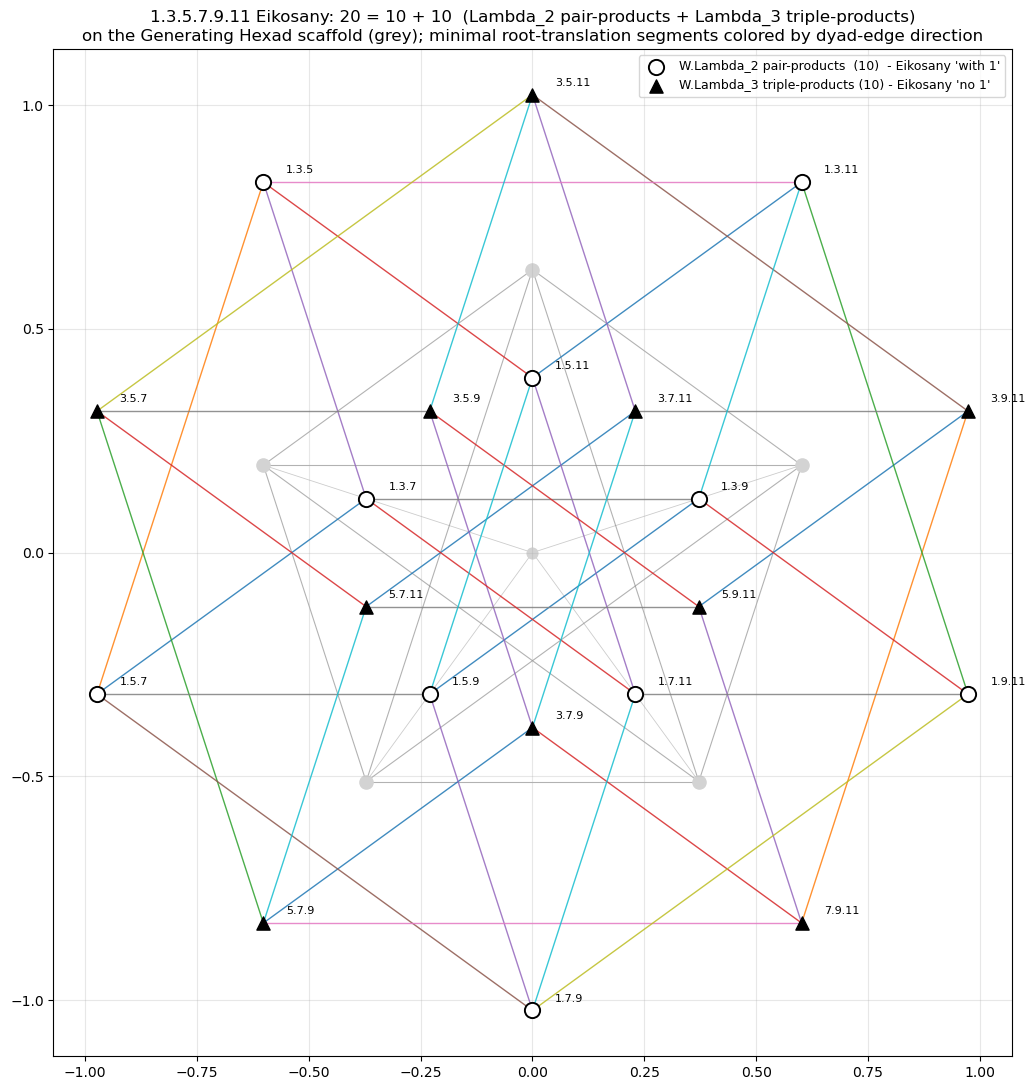

In [10]:
# Eikosany = W.Lambda_2  sqcup  W.Lambda_3
eikosany_5D = np.vstack([L2, L3])
assert len(eikosany_5D) == 20

xy_e = eikosany_5D @ proj.T
x_e  = -xy_e[:, 1]
y_e  =  xy_e[:, 0]

# Hexad scaffold (light grey) - context for the Eikosany on the Generating Hexad
xy_h = otonal_5D @ proj.T
xh_, yh_ = -xy_h[:, 1], xy_h[:, 0]

fig, ax = plt.subplots(figsize=(11, 11))

ax.scatter(xh_, yh_, color="lightgrey", s=90, zorder=1)
ax.scatter([0], [0], color="lightgrey", s=60, zorder=1)
for i, j in itertools.combinations(range(5), 2):
    ax.plot([xh_[i], xh_[j]], [yh_[i], yh_[j]],
            color="grey", linewidth=0.8, alpha=0.6, zorder=0)
for k in range(5):
    ax.plot([0, xh_[k]], [0, yh_[k]],
            color="grey", linewidth=0.6, alpha=0.4, zorder=0)

# Connecting lines: pairs of Eikosany points connected by a root translation
# alpha = e_i - e_j. Each such pair is a parallel translate of the Generating Hexad's
# (i, j) dyad-edge and is drawn in dyad_colors[(i, j)]. Parallel (same-slope) lines
# therefore share a color across the Generating Hexad and here.
def root_to_pair(r5):
    """For a root vector e_i - e_j, return the unordered pair (min, max) of indices."""
    i = int(np.where(np.asarray(r5) ==  1)[0][0])
    j = int(np.where(np.asarray(r5) == -1)[0][0])
    return (min(i, j), max(i, j))

def find_in_eikosany(target_vec):
    """Return index of target_vec in eikosany_5D, or -1 if not present.

    Uses direct numpy array comparison rather than tuple-hashing, to avoid any
    SageMath/Python dtype mismatch that would silently fail dict lookups.
    """
    matches = np.where((eikosany_5D == target_vec).all(axis=1))[0]
    return int(matches[0]) if len(matches) else -1

def segment_has_interior_eikosany_point(k, m):
    """True if any Eikosany point other than k, m lies strictly inside the projected
    2D segment from k to m. Used to suppress non-minimal root-translation segments
    that would overlay an intermediate point and create a visual phantom connection
    between two non-root-related endpoints."""
    ax_, ay_ = x_e[k], y_e[k]
    dx, dy   = x_e[m] - ax_, y_e[m] - ay_
    seg_L2   = dx * dx + dy * dy
    for p in range(len(eikosany_5D)):
        if p == k or p == m:
            continue
        px, py = x_e[p] - ax_, y_e[p] - ay_
        cross  = dx * py - dy * px
        if abs(cross) > 1e-6 * (seg_L2 ** 0.5):
            continue
        t = (px * dx + py * dy) / seg_L2
        if 1e-6 < t < 1 - 1e-6:
            return True
    return False

n_drawn = n_skipped = 0
for alpha in pos_roots:
    pair  = root_to_pair(alpha)
    color = dyad_colors[pair]
    for k in range(len(eikosany_5D)):
        m = find_in_eikosany(eikosany_5D[k] + alpha)
        if m < 0:
            continue
        if segment_has_interior_eikosany_point(k, m):
            n_skipped += 1
            continue
        ax.plot([x_e[k], x_e[m]], [y_e[k], y_e[m]],
                color=color, linewidth=1.0, alpha=0.85, zorder=2)
        n_drawn += 1

print(f"Drew {n_drawn} minimal root-translation segments; "
      f"suppressed {n_skipped} non-minimal segments that overlay an intermediate "
      f"Eikosany point in the 2D projection (60 total root-pairs).")

# Markers: open circles for Lambda_2 pair-products, filled triangles for Lambda_3 triple-products.
# Neutral (black) so the colored lines carry the directional information.
n2 = len(L2)
ax.scatter(x_e[:n2], y_e[:n2],
           facecolors="white", edgecolors="black", s=120, linewidths=1.4,
           label=f"W.Lambda_2 pair-products  ({n2})  - Eikosany 'with 1'", zorder=4)
ax.scatter(x_e[n2:], y_e[n2:], marker="^", color="black", s=90,
           label=f"W.Lambda_3 triple-products ({len(L3)}) - Eikosany 'no 1'", zorder=4)

# Product-form annotations
for k, v in enumerate(eikosany_5D):
    ax.annotate(product_label(v), xy=(x_e[k]+0.05, y_e[k]+0.02),
                fontsize=8, zorder=5)

ax.set_aspect("equal")
ax.set_title(f"1.3.5.7.9.11 Eikosany: {len(eikosany_5D)} = 10 + 10  "
             f"(Lambda_2 pair-products + Lambda_3 triple-products)\n"
             f"on the Generating Hexad scaffold (grey); "
             f"minimal root-translation segments colored by dyad-edge direction")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig('../pentadic_eikosany.png')
plt.show()

## Eikosany--Diamond overlay

There is a further connection between the Hexadic Diamond and the Eikosany: a $C_5$ orbit of the Coxeter element $c = s_1 s_2 s_3 s_4$ acting on appropriately chosen $\Lambda_2$ and $\Lambda_3$ seeds generates **10 outer-ring divisors** whose 10 Eikosany translates **jointly cover all 31 Diamond points**. The count $10 = |D_5|$ is dihedral (the symmetry of the pentagon) rather than Pascal -- a different symmetry takes over.

For the full overlay construction -- variant enumeration, Coxeter-orbit seed selection, HEJI-form factorisation labels, and the per-variant coverage statistics -- see [`notebooks/eikosany_diamond_coxeter.ipynb`](eikosany_diamond_coxeter.ipynb). The treatment of the *inverse* Eikosany (Wilson's barred Generating Hexad in Figure 13, generating $-\Lambda_2 \sqcup -\Lambda_3$) also belongs to that follow-on notebook.